In [1]:
import sys 
sys.path.append('../..')

import jax
from functools import partial
from jax import grad, jacfwd, vmap, jit, hessian, value_and_grad
from jax.lax import scan
# from jax.ops import index_update, index
import jax.random as jnp_random
import jax.numpy as np

from jax.flatten_util import ravel_pytree

import numpy as onp
from time_opt_erg_lib.ergodic_metric import ErgodicMetric
from time_opt_erg_lib.fourier_utils import BasisFunc, get_phik, get_ck, recon_from_fourier
from IPython.display import clear_output
import matplotlib.pyplot as plt

from time_opt_erg_lib.opt_solver import AugmentedLagrangeSolver
from time_opt_erg_lib.target_distribution import TargetDistribution
import yaml
import pickle as pkl


In [2]:
def get_phik(vals, basis):
    _phi, _x = vals 
    phik = np.dot(_phi, vmap(basis.fk_vmap)(_x))
    phik = phik/phik[0]
    # phik = phik/basis.hk_list
    return phik

In [3]:
basis = BasisFunc([20]*2)
metric = ErgodicMetric(basis)

unif = TargetDistribution()
phik = get_phik(unif.evals, basis)

I0000 00:00:1714855878.305874       1 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.


In [4]:
np.sum(metric.lamk@phik**2)

Array(1.0802962, dtype=float32)

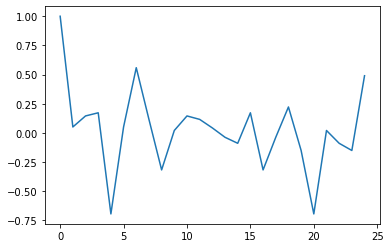

In [20]:
plt.plot(phik)

In [ ]:
def loss(params):
    x1 = params['x1']
    x2 = params['x2']
    ck1 = get_ck(x1.reshape((1,-1)), basis, 1, 1) 
    ck2 = get_ck(x2.reshape((1,-1)), basis, 1, 1) 
    return metric(ck1, ck2)

params = {
    'x1' : np.array([0.2,0.3]),
    'x2' : np.array([0.8,0.7])
}
for _ in range(100):
    d_params = grad(loss)(params)
    params['x1'] = params['x1'] + 0.001*d_params['x1']
    params['x2'] = params['x2'] + 0.001*d_params['x2']
    print(params, loss(params))

In [37]:
x1 = np.array([0.9,0.95])

ck1 = get_ck(x1.reshape((1,-1)), basis, 1, 1)

In [38]:
metric.lamk@ck1**2

Array(4.240346, dtype=float32)

In [78]:
n_basis = []
metric_val = []
for _n_basis in range(1, 200, 5):
    n_basis.append(_n_basis)
    basis = BasisFunc([_n_basis]*2)
    metric = ErgodicMetric(basis)
    x1 = np.array([0.5,0.5])
    x2 = np.array([0.75,0.8])
    ck1 = get_ck(x1.reshape((1,-1)), basis, 1, 1) 
    ck2 = get_ck(x2.reshape((1,-1)), basis, 1, 1)
    metric_val.append(np.sum((ck1-ck2)**2))

In [83]:
np.exp(1)*2

Array(5.4365635, dtype=float32, weak_type=True)

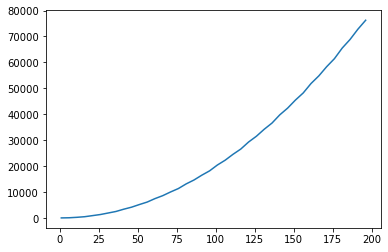

In [79]:
plt.plot(n_basis, metric_val)

In [64]:
def get_metric_val(x1, x2, _n_basis=100):
    basis = BasisFunc([_n_basis]*2)
    metric = ErgodicMetric(basis)
    ck1 = get_ck(x1.reshape((1,-1)), basis, 1, 1) 
    ck2 = get_ck(x2, basis, 1, 1)
    return metric(ck1, ck2)

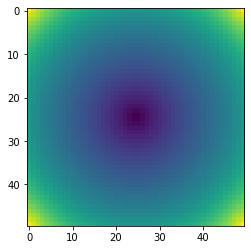

In [49]:
plt.imshow(out_vals.reshape(domain[0].shape))

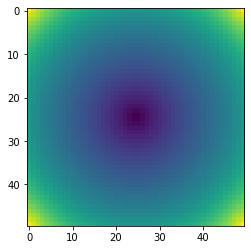

In [51]:
plt.imshow(out_vals.reshape(domain[0].shape))

In [77]:
out_vals.max()

Array(5.960867, dtype=float32)

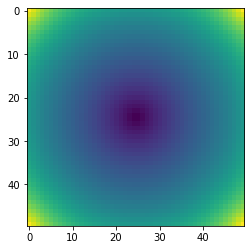

In [73]:
plt.imshow(out_vals.reshape(domain[0].shape))

In [74]:
out_vals = vmap(get_metric_val, in_axes=(0,None,None))(x_vals, np.array([[.5,.5]]), 10)

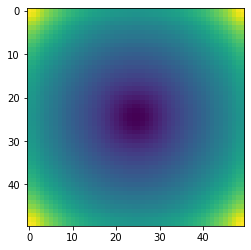

In [75]:
plt.imshow(out_vals.reshape(domain[0].shape))

In [72]:
out_vals

Array([6.638289 , 6.2877855, 5.9528217, ..., 5.952821 , 6.287786 ,
       6.6382885], dtype=float32)

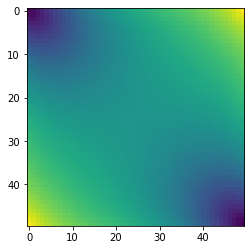

In [68]:
plt.imshow(out_vals.reshape(domain[0].shape))

In [36]:
metric_val

[Array(0., dtype=float32),
 Array(2.2163885, dtype=float32),
 Array(2.4645295, dtype=float32),
 Array(2.541094, dtype=float32),
 Array(2.5916338, dtype=float32),
 Array(2.615362, dtype=float32),
 Array(2.6341941, dtype=float32),
 Array(2.6459067, dtype=float32),
 Array(2.657176, dtype=float32),
 Array(2.6639977, dtype=float32),
 Array(2.6704395, dtype=float32),
 Array(2.6749723, dtype=float32),
 Array(2.6797974, dtype=float32),
 Array(2.6829832, dtype=float32),
 Array(2.686181, dtype=float32),
 Array(2.6885698, dtype=float32),
 Array(2.6912394, dtype=float32),
 Array(2.6930773, dtype=float32),
 Array(2.6949928, dtype=float32),
 Array(2.6964643, dtype=float32),
 Array(2.698155, dtype=float32),
 Array(2.6993499, dtype=float32),
 Array(2.700619, dtype=float32),
 Array(2.7016156, dtype=float32),
 Array(2.7027822, dtype=float32),
 Array(2.7036204, dtype=float32),
 Array(2.7045262, dtype=float32),
 Array(2.705246, dtype=float32),
 Array(2.7060986, dtype=float32),
 Array(2.7067182, dtype=floa

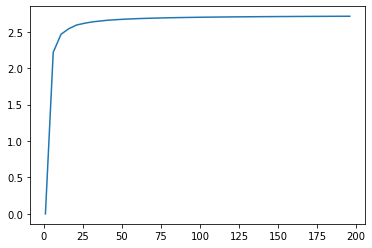

In [37]:
plt.plot(n_basis, metric_val)

In [21]:
domain = np.meshgrid(
    *[
        np.linspace(0,1),
        np.linspace(0,1)
    ]
)
x_vals = np.stack([X.ravel() for X in domain]).T
phi_vals = recon_from_fourier(ck1, basis, basis.k_list, x_vals)

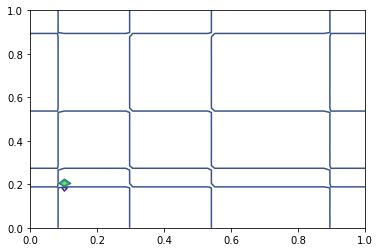

In [22]:
plt.contour(domain[0], domain[1], phi_vals.reshape(domain[0].shape))